<a href="https://colab.research.google.com/github/mullinskatie7-source/katherine-mullins.github.io/blob/main/Katherine_Mullins_Continuous_Probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Wind Turbine Gearbox Maintenance

**Engineer:** Katherine Mullins

**Completion Date:** 09/21/2026

**Class:** EGN3443

**Assignment #:** 5

**Tool Used:** Colab / Python

## Problem Description

The objective of this analysis is to determine which continuous probability distribution best represents the Time Between Failures of 100 wind turbine gearboxes. Candidate distributions will be fitted to the measured gearbox failure data and evaluated using graphical and statistical goodness-of-fit methods.

Once an appropriate distribution has been selected, the model will be used to determine preventive-maintenance cycles corresponding to reliability levels of 80%, 90%, and 95%. These intervals represent maintenance times at which no more than 20%, 10%, and 5% of gearboxes, respectively, are expected to have experienced a failure.

## Methodology

Python and the SciPy statistical library were used to analyze the 100 gearbox Time Between Failures measurements. Normal, Exponential, Weibull, and Lognormal distributions were fitted to the data. Their fits were compared using probability-density plots, the Kolmogorov-Smirnov goodness-of-fit statistic, and Akaike Information Criterion values.

The Weibull distribution was selected as the best-fitting model. Its shape and scale parameters were estimated from the observed TBF measurements. The Weibull cumulative distribution and reliability functions were then used to determine the time corresponding to 20%, 10%, and 5% cumulative failure probabilities. These times define maintenance intervals for 80%, 90%, and 95% reliability, respectively.

Number of gearboxes: 100
Mean TBF: 23.457 months
Median TBF: 23.685 months
Standard deviation: 2.807 months
Minimum TBF: 14.29
Maximum TBF: 29.73
--- Distribution Fit Comparison ---
Normal       KS = 0.0833, p = 0.4669, AIC = 493.18
Exponential  KS = 0.5008, p = 0.0000, AIC = 835.03
Weibull      KS = 0.0697, p = 0.6900, AIC = 490.00
Lognormal    KS = 0.1105, p = 0.1613, AIC = 502.90
--- Weibull Parameters ---
Shape parameter (k): 9.7257
Scale parameter (lambda): 24.6517 months
--- Recommended Maintenance Cycles ---
80% Reliability: 21.13 months
90% Reliability: 19.56 months
95% Reliability: 18.16 months


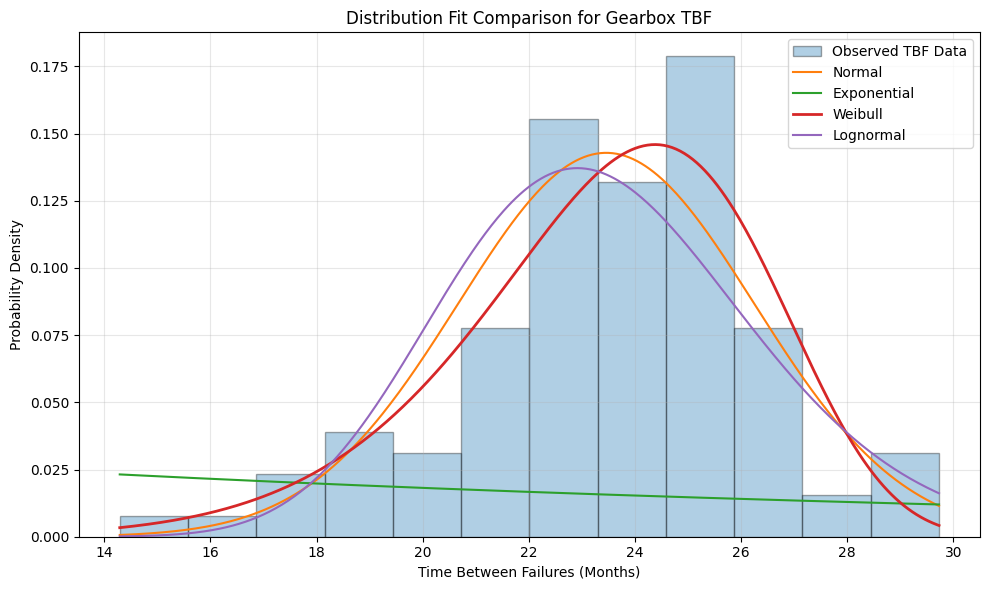

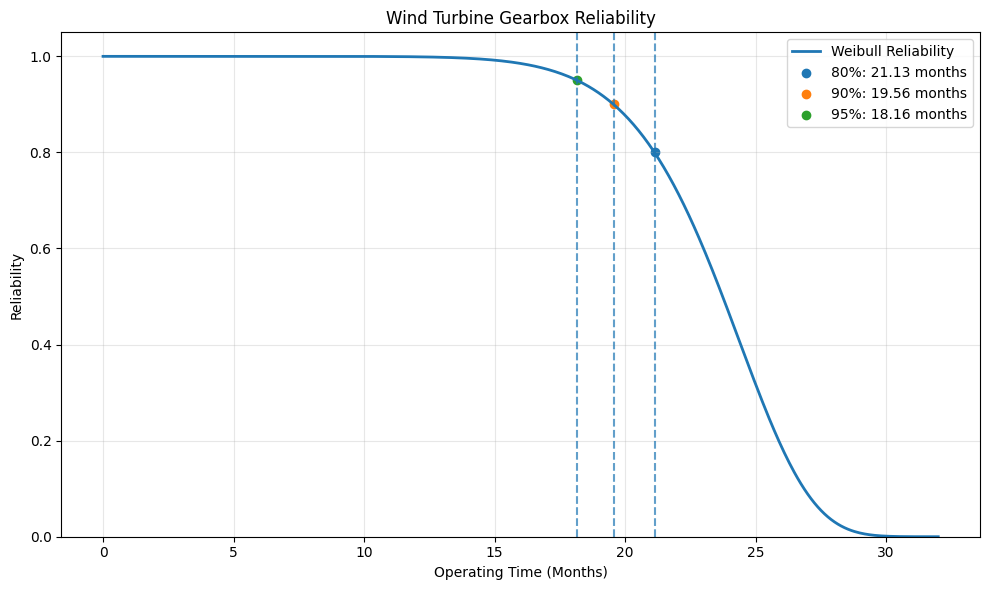

In [1]:
# Step 2: Import data and libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Time Between Failures (months)
tbf = np.array([
28.36, 18.42, 24.15, 26.82, 17.68, 22.91, 21.07, 29.73, 25.94, 23.56,
27.05, 14.29, 19.52, 25.36, 22.36, 23.34, 29.04, 23.72, 24.99, 20.46,
18.55, 22.33, 27.44, 24.64, 25.46, 26.16, 28.65, 16.77, 18.63, 25.09,
25.24, 26.62, 21.71, 19.37, 17.85, 24.85, 21.58, 22.03, 17.12, 25.34,
23.65, 22.75, 24.11, 25.29, 18.97, 22.74, 22.58, 24.73, 25.65, 21.45,
22.87, 24.53, 29.07, 21.29, 26.06, 23.62, 25.84, 20.72, 25.02, 27.01,
22.68, 25.31, 19.64, 23.11, 24.36, 24.73, 21.48, 25.92, 26.02, 22.08,
22.94, 24.49, 20.85, 25.87, 22.43, 22.59, 25.47, 20.83, 22.86, 21.75,
24.03, 22.76, 25.32, 23.87, 24.09, 25.56, 22.45, 25.27, 23.94, 25.19,
22.97, 23.33, 24.79, 21.88, 23.62, 25.22, 22.47, 24.87, 22.65, 23.85
])

print("Number of gearboxes:", len(tbf))
print("Mean TBF:", round(np.mean(tbf), 3), "months")
print("Median TBF:", round(np.median(tbf), 3), "months")
print("Standard deviation:", round(np.std(tbf, ddof=1), 3), "months")
print("Minimum TBF:", np.min(tbf))
print("Maximum TBF:", np.max(tbf))

# Step 3: Fit candidate distributions

normal_params = stats.norm.fit(tbf)

# Positive-valued distributions are constrained to start at zero
exponential_params = stats.expon.fit(tbf, floc=0)
weibull_params = stats.weibull_min.fit(tbf, floc=0)
lognormal_params = stats.lognorm.fit(tbf, floc=0)

distributions = {
    "Normal": (stats.norm, normal_params),
    "Exponential": (stats.expon, exponential_params),
    "Weibull": (stats.weibull_min, weibull_params),
    "Lognormal": (stats.lognorm, lognormal_params)
}

print("--- Distribution Fit Comparison ---")

for name, (dist, params) in distributions.items():

    # Kolmogorov-Smirnov goodness-of-fit test
    ks_stat, p_value = stats.kstest(tbf, dist.cdf, args=params)

    # Log likelihood
    log_likelihood = np.sum(dist.logpdf(tbf, *params))

    # All models use two fitted parameters here
    aic = 2 * 2 - 2 * log_likelihood

    print(
        f"{name:12s} "
        f"KS = {ks_stat:.4f}, "
        f"p = {p_value:.4f}, "
        f"AIC = {aic:.2f}"
    )

# Step 4: Weibull Parameters
shape, location, scale = weibull_params

print("--- Weibull Parameters ---")
print(f"Shape parameter (k): {shape:.4f}")
print(f"Scale parameter (lambda): {scale:.4f} months")

# Step 5: Desired reliability levels
reliability_levels = [0.80, 0.90, 0.95]

print("--- Recommended Maintenance Cycles ---")

for reliability in reliability_levels:

    # Failure probability = 1 - reliability
    failure_probability = 1 - reliability

    # Find the time corresponding to that cumulative failure probability
    maintenance_time = stats.weibull_min.ppf(
        failure_probability,
        shape,
        loc=0,
        scale=scale
    )

    print(
        f"{reliability*100:.0f}% Reliability: "
        f"{maintenance_time:.2f} months"
    )

# Step 6: Distrubution Comparison Plot
x = np.linspace(min(tbf), max(tbf), 400)

plt.figure(figsize=(10, 6))

# Actual data histogram
plt.hist(
    tbf,
    bins=12,
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="Observed TBF Data"
)

# Plot candidate distributions
plt.plot(
    x,
    stats.norm.pdf(x, *normal_params),
    label="Normal"
)

plt.plot(
    x,
    stats.expon.pdf(x, *exponential_params),
    label="Exponential"
)

plt.plot(
    x,
    stats.weibull_min.pdf(x, *weibull_params),
    linewidth=2,
    label="Weibull"
)

plt.plot(
    x,
    stats.lognorm.pdf(x, *lognormal_params),
    label="Lognormal"
)

plt.title("Distribution Fit Comparison for Gearbox TBF")
plt.xlabel("Time Between Failures (Months)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Step 7: Reliability Curve
time = np.linspace(0, 32, 500)

reliability = stats.weibull_min.sf(
    time,
    shape,
    loc=0,
    scale=scale
)

plt.figure(figsize=(10, 6))

plt.plot(
    time,
    reliability,
    linewidth=2,
    label="Weibull Reliability"
)

# Maintenance thresholds
maintenance_levels = {
    "80%": 21.13,
    "90%": 19.56,
    "95%": 18.16
}

for label, month in maintenance_levels.items():

    reliability_value = float(label.strip("%")) / 100

    plt.axvline(
        month,
        linestyle="--",
        alpha=0.7
    )

    plt.scatter(
        month,
        reliability_value,
        label=f"{label}: {month:.2f} months"
    )

plt.title("Wind Turbine Gearbox Reliability")
plt.xlabel("Operating Time (Months)")
plt.ylabel("Reliability")

plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()